<a href="https://colab.research.google.com/github/TherealArithmeticProgression/pytorch-tutorials-with-detailed-annotations/blob/main/Quickstart_Annotated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FashionMNIST Classifier - from PyTorch Quickstart

Annotated implementation of a rather simple image classifier. Trained on the Modified National Institute of Standards and Technology's Fashion dataset. It provides a clever walkthrough of the following: data loading, model definition, optimization and other aspects.

### What's a dataloader?

*  Dataset is a python object.
*  It has two methods: __len__ (how many items?) and __getitem__ (give me item at index i). Doing train_data[2] returns 3rd image and the label tupple.

*  A dataloader is a "wrapper" around the Dataset. It surther enables us to perform some tasks.
*  Dataloader is an iterator. An iterator is a method. It's used extensively in languages, including Python.
* For instance, when you write 'for i in range(0,9):' - python takes output from the range(x,y) function, puts the output in a list. converts the list into an iter. Repeatedly calls next() on the iter object.
* On the last object, it hits a 'StopIteration' exception (try... exception - and in the exception block there's code that liberates the iter() object). If you're no longer referencing the object, Python's garbage collector will clean it up on your behalf. Otherwise it may exist in the memory.

## Hazard: Understand how iterator, iterant and iterable are different from each other.

* An __iterable__ is a lot of tensors (array of tensors).
* The __iterator__ we obtain when we give the array of tensors to the iter() method and it coverts it into an iterator object.
* the __value__ that is held __inside__ the __iterator__, just after applying next() method is the __iterant__.


In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

print('='*15)
print(f'PyTorch version {torch.__version__} imported successfully. ')
print('='*15)

PyTorch version 2.10.0+cpu imported successfully. 


## Why did we use v2?
* V2 refers to the API transform we used.
* An API transform, in computer vision, helps models learn better.
* If there's finite data, and you'd still the model to train on the images, you can modify the available data: resize the images, enhance or decrease resolution, rotate the image, etc.
* Such data allows the model to learn the nuances and familiarize with the patterns arising in the pixel values.
* V1 was not as structure agnostic as V2 is (doesn't work well with dataframes/tupples/lists etc)

In [ ]:
'''
 Every torchvision dataset includes two arguements: transform and target_transform. Using either of
these we can modify the sample and label (respectively, of course).'
'''
# Downloading training data.
train_data=datasets.FashionMNIST(
    root='data',
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)



# Downloading the testing data.
test_data=datasets.FashionMNIST(
    root='data',
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

print("Dataset imported for training and testing purposes.")


Dataset imported for training and testing purposes.


## Comprehending the compose pipeline.

### ToImage()
* Converts to a pytorch friendly Image tensor (a tensor, in simple terms is a 3D array).
### ToDtype(torch.float32, scale=True)
* A neural network learns best when the tensor elements are little. So we convert integers/decimals such as 255 to 255.0 (float), and divide by 255. All numbers now lie between 0.0 and 1.0

In [ ]:
size_obatch=8**2

'''
Dataloader wraps an iterable over the dataset. What exactly is this wrapping
called iterable? When can we use this for?
Iterable wrapping can support automatic batching, sampling, shuffling,
and multiprocess data loading. 1 element in data loader iterable
will give one batch of 64 features and labels.
'''
train_dataloader=DataLoader(train_data, batch_size=size_obatch)
test_dataloader=DataLoader(test_data, batch_size=size_obatch)

for X,y in test_dataloader:
  print(f"Shape of [N, C, H, W]: {X.shape}")
  '''
  what does N, C, H, W stand for?
  '''
  print(f"Shape of y: {y.shape} {y.dtype}")
  break


Shape of [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


* __Number__
Refers to number of images in a single batch. We've fixed this value as '8**2' (64).


* __Channels__
A standard image has 3 channels (Red, Green and Blue). FashionMNIST dataset contains grey scale image, thereby there's only a single channel.

* __Height__
Vertical pixel resolution.

* __Width__
Horizontal pixel resolution (count of pixels).

### Trivial Info

Both OpenCV and TensorFlow default to NHWC, but PyTorch defaults to NCHW to compy with Nvidia's GPU architecture.


In [ ]:
device='cpu'
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.flatten=nn.Flatten()
    self.linear_relu_stack=nn.Sequential(
        nn.Linear(28*28,512),
        nn.ReLU(),
        nn.Linear(512,512),
        nn.ReLU(),
        nn.Linear(512,10)
    )

  def forward(self, x):
    x=self.flatten(x)
    logits=self.linear_relu_stack(x)
    return logits


model=NeuralNetwork().to(device)
print(model)



NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


*  super().__ init __() calls the constructor of nn module. The constructor is = two calls.
1. First call to __new__(). (reserve certain bytes of memories for incoming object), and
2. second call to __init__() (populate vacant block of memory with new info).
* nn.flatten() implies: reshape the data. You have data in the format NCHW. We'll unroll the data into a 2D matrix. How?
* * __Strides-bred illusions__: When you create a tensor, PyTorch stores two things in the memory:
* * 1. Storage Array (all data in one single array, say [N, C, H, W, N', C', H... and so on]).
* * 2. Metadata (contains shape and strides.) Shaped similar to this:

tensor_metadata = {

    "data_ptr": 0x7f9812ab3000,       # The raw memory address where the long list starts
    "shape": (64, 1, 28, 28),         # The dimension tuple you see
    "strides": (784, 784, 28, 1),     # The step-size tuple Python uses to hop through memory
    "dtype": torch.float32,           # Data type (e.g., 4 bytes per number)
    "device": "cpu"                   # Where the memory lives
}
* * * __NOTE__ The shape and strides are tupple to prevent excessive tempering with this data.

*  nn.sequential: performs all the functions in a particular order.
* The forward() method multiplies weights and biases, and provides us logits. Logits tensor is a tensor of this sort of data: [2.3, -1.2, 0.5, 4.8, -3.1, 0.1, 1.4, -0.9, 0.2, -2.5] - there are 10 categories of clothes, and each category  has a score. The score is unnormalized (doesn't lie between 0 and 1), so the number could be negative. The max number corresponds to a particular category, and in classification the category corresponding to that number is chosen as the output.
* *  __Softmax__ is the trick used in PyTorch to normalize the scores between 0.0 to 1.0, and additionally, __torch.argmax()__ can be used to come up with the winning category.

*There's going to be one loop. The model will make prediction on the training dataset.
The data will be fed in batches. Each batch contains 64 images. It backpropagates
the prediction error and adjusts the model's Parameters.*

In [ ]:
# Loss function and optimizer are required for training a model.

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(model.parameters(), lr=1e-3)


def train(dataloader, model, loss_fn, optimizer):
  size=len(dataloader.dataset)
  model.train()
  for batch, (X,y) in enumerate(dataloader):
    X, y = X.to(device), y.to(device)
    # Not required if you're working with cpus as default, although fun to keep.
    pred=model(X)
    loss=loss_fn(pred,y)
    # Backpropagation
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch%100==0:
      loss, current=loss.item(), ( batch+1)*len(X)




* torch.optim.SGD(parameters, lr)
* * SGD is stochastic gradient descent, a classic, widely used benchmark optimizing algorithm. It takes two arguements: parameters (describing where you've put the weights and biases - the location/memory addresses in the RAM) and learning rate (here it's 1 * 10ᵃ,  a= -3).

* What exactly does the learning rate represent? It's supposed to be a dimensionless quantity.
* * The learning rate is used for computing the step size as follows: `(step_size)=(learning_rate)*(Gradient_Value)`

* Do the weights increase or decrease in intervals of the step size?
* * The step size *doesn't decide* __by how much the weights change__ (that requires calculus).

* How do you calculate cross entropy loss?
** The process can be (in a simplified terms), be represented as:

``
Softmax->(Normalization) - > Logits converted to probability (between 0 and 1) - > loss = -ln(p)
``
## Backpropagation

loss = loss_fn(pred,y) obtains the loss as follows:
`ln(y) - ln(pred) ` which than a consequence of mathematics evolves as: `-ln(pred)`.
>  __NOTE__ The "ln(pred)" employed in the above calculation refers to the max value out of the assigned logits to each category.
* * Let's simplify this by taking the earlier logits. The hypothetical logits were:

[2.3, -1.2, 0.5, 4.8, -3.1, 0.1, 1.4, -0.9, 0.2, -2.5]
.

Consider the image of each logit under the exponential function (y=eˣ)
* * Our new logits are:

 [9.974, 0.301, 1.649, 121.510, 0.045, 1.105, 4.055, 0.407, 1.221; 0.082]
* * Their sum = 140.348. We divide each value by the value of their sum, and we obtain a new logits list:

[0.071, 0.002, 0.012, 0.86, 0.003, 0.08, 0.29, 0.029, 0.008, 0.006]

__y(pred)__ in this case would be: 0.86. And since the ideal probability (logit ditribution in y would be of the form:[

0, 0, 0, 1, 0, 0, 0, 0, 0, 0]

The difference so obtained would be: ln(1)-ln(0.86).

---
### Intepreting loss.backward()

__loss.backward()__ calls pytorch's automatic differentation engine `autograd`, at the end of the final cross entropy loss value, PyTorch calculates the gradient of the loss with respect to every single variable of the system. It does NOT change the weights.
* __The hidden memory slot__:  There's hidden sister memory slot called __.grad__ which is opened by autograd and the partial derivatives are placed inside the memory location. The weights will now be updated by __optimizer.step()__

## Cleaning the grad location

The calculations have changed the weights. To clean the hidden .grad location, we use the function optimizer.zero_grad(), and it essentially removes the previously sotred values concerning the old weights.

---
## The purpose of the if loop at the bottom:

`loss=loss.item`
loss is a PyTorch tensor. It'd resemble this: [0,0,0,0,0.23,0,0,0,0], but upon carrying out the above mentioned command, loss becomes = 0.23 (yep. all the unnecessary data is lost to voids).

`current=(batch+1)*(len(X))`
The code is a counter. It reflects what image you're currently on. 0,1,2,3... etc

In [ ]:
def test(dataloader, model, loss_fun):
  size=len(dataloader.dataset)
  num_batches=len(dataloader)
  model.eval()
  test_loss, correct=0,0
  with torch.no_grad():
    for _, (X, y) in enumerate(dataloader):
      X,y=X.to(device), y.to(device)
      pred=model(X)
      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1)==y).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy {(100*correct):>0.1f}%, Avg loss= {test_loss:>8f} \n")



## model.eval()

A neural network has various layers. Layers have weights (it's a bunch of matrices). There are layers called __dropout layers__ which have a tendency of shutting off randomly. This forces the network tolook for alternative solutions. But during evaluation, we want the model to give it's best. model.eval() assures the model is well behaved.

___
* What is with doing here?
* * with starts a context manager. It's like saying: while you are inside this block, assure the condition (set it to true, and in this case we're forcing it to stop calling autograd to keep updating the weights), and outside it, set it to True or False. Nobody cares. The `loss.backward()` does not get called in this case.

___
* Why does correct only account the times when the network was absolutely correct (when argmax() gave one)

* * Loss function attributes little loss to cases when the differences are highly skewed in the logits (loss for [0.01, 0.02, 0.90, 0.02, 0.02, 0.02, 0.02] is less than that in a case akin to this: [0.21, 0.02, 0.10, 0.12, 0.22, 0.32, 0.01]). Correct only considers how absolutely correct the model has been.

In [ ]:
epochs=9
for t in range(epochs):
  print(f"Epoch {t+1}\n {'-'*9}")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)


print("Done!")

Epoch 1
 ---------
Test Error: 
 Accuracy 66.1%, Avg loss= 0.982565 

Epoch 2
 ---------
Test Error: 
 Accuracy 67.2%, Avg loss= 0.909663 

Epoch 3
 ---------
Test Error: 
 Accuracy 68.4%, Avg loss= 0.857252 

Epoch 4
 ---------
Test Error: 
 Accuracy 69.6%, Avg loss= 0.817790 

Epoch 5
 ---------
Test Error: 
 Accuracy 70.8%, Avg loss= 0.786645 

Epoch 6
 ---------
Test Error: 
 Accuracy 71.9%, Avg loss= 0.760915 

Epoch 7
 ---------
Test Error: 
 Accuracy 72.9%, Avg loss= 0.738824 

Epoch 8
 ---------
Test Error: 
 Accuracy 74.1%, Avg loss= 0.719291 

Epoch 9
 ---------
Test Error: 
 Accuracy 74.9%, Avg loss= 0.701656 

Done!


We'll run 9 epochs (rounds) of training and testing consequently. The optimizer will only be an arguement for the training method, and the consequent accuracy will reflect as the epochs proceed.

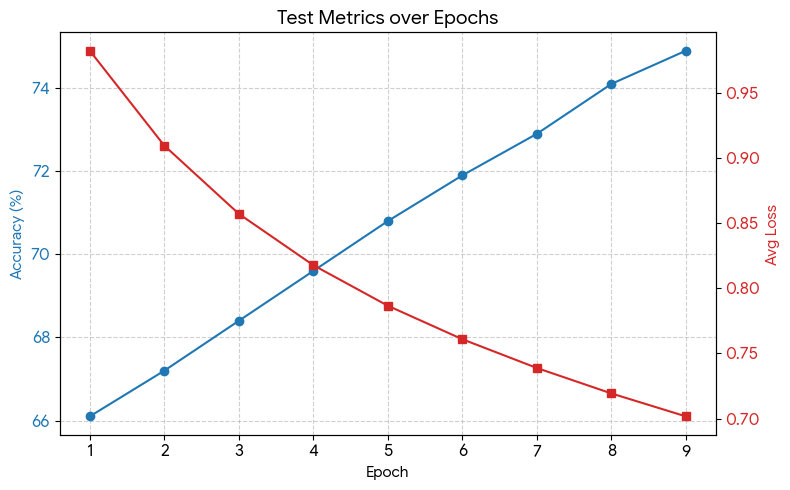